# Updating Dataframes

In this lesson we will introduce methods for updating a `pandas.DataFrame`. These include adding and removing columns and updating specific values.

# Data

Palmer Penguins dataset [1] developed by Drs. Allison Horst, Alison Hill and Kristen Gorman. This dataset contains size measurements for three penguin species in the Palmer Archipelago, Antarctica during 2007, 2008, and 2009.

In [3]:
import numpy as np
import pandas as pd

# Create a random number generator with a seed
rng = np.random.default_rng(seed=42)

# Import data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

# Using a dictionary-like syntax

The simplest syntax to add a new column to a `pandas.DataFrame` is

```python
df['new_col_name'] = new_column_values
```

where the `new_column_values` could be:

- a `pandas.Series` or a `numpy.array` of the same length as the data frame, or
- a single scalar.
When the new values are a pandas.Series, pandas matches them to rows by index label, not by position, so rows with no matching label get `NaN`.

If the column name exists, the existing column will be updated.

Remember a `pandas.DataFrame` can be seen as a dictionary of its columns. This syntax for adding a new column to a `pandas.DataFrame` is the same as adding a new key-value pair to a dictionary:

```python
dict[new_key] = new_value
```


*Example*:

We want to create a new column where the body mass is in kilograms instead of grams, then we need to divide each value in the body_mass_g column by 1000.

In [5]:
# Add new column body_mass_kg 
penguins['body_mass_kg'] = penguins['body_mass_g']/1000

# Confirm the new column is in the data frame
print("body_mass_kg is in the data frame's columns: ", 'body_mass_kg' in penguins.columns)

# Look at the new column
penguins.head()

body_mass_kg is in the data frame's columns:  True


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_mass_kg
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,3.75
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,3.80
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,3.25
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,3.45


# Using the `assign()` method

We can also create or update an existing column using the `assign()` method for `pandas.DataFrames`. The general syntax is:

```python
df = df.assign(new_col_name=new_column_values)
```

Notice the new column names are not strings. We declare them as if we were creating variables.

This way of creating a new column, unlike the dictionary-like syntax, does not modify the data frame in place. This can be useful for chaining operations:


<Axes: xlabel='bill_length_cm', ylabel='body_mass_g'>

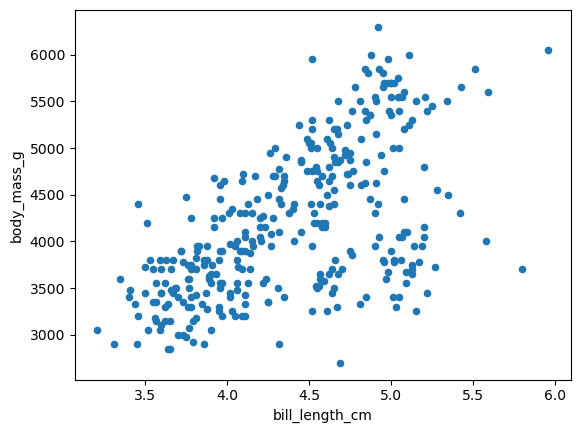

In [6]:
(penguins.assign(bill_length_cm=penguins['bill_length_mm']/10)
        .plot(kind='scatter',
              x='bill_length_cm', 
              y='body_mass_g')
    )

Read a chain like this from top to bottom: each method acts on the output of the line before it. Here, `assign()` returns a new data frame with the `bill_length_cm` column, and `plot()` makes a scatter plot from that data frame. Wrapping the whole expression in parentheses lets us split it across several lines, one method per line, without Python raising a syntax error.

# At a specific location

The new column was added by default at the end of the data frame. If we want to create a new column and insert it at a particular position we can use the data frame method `insert()`:

```python
df.insert(loc=integer_index,  # Location of new column
          column='new_col_name', 
          value=new_col_values)
```

*Example*: 

Let’s give each penguin observation a unique identifier as a three-digit number and add this column at the beginning of the data frame.



In [8]:
# Create random 3-digit codes
codes = rng.choice(np.arange(100, 1000), size=len(penguins), replace=False)  # Sampling w/o replacement

# Insert codes at the front of data frame
penguins.insert(loc=0,  # First position
                column='id_code',
                value=codes)
        
penguins.head()

,id_code,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_mass_kg
0,630,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,3.75
1,679,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,3.80
2,175,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,3.25
3,330,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007,NaN
4,355,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,3.45


# Adding multiple columns

We can also use the `assign()` method to create or update multiple columns in the same call. 

The general syntax is:
```python
df = df.assign(new_col1_name=new_col1_values, 
               new_col2_name=new_col2_values)
```
Remember this method does not modify the data frame, so you will need to reassign the output to the original data frame to update it.

*Example*: 

Suppose we want to add these new columns:

- flipper length converted from mm to cm, and
- a code representing the observer.

We can add these columns to `penguins` using `assign()`:

In [10]:
# Create columns with observer codes and flipper length in cm
penguins = penguins.assign(flipper_length_cm=penguins['flipper_length_mm']/10, 
                           observer=rng.choice(['A','B','C'],  # Sample with replacement
                                               size=len(penguins))
                          )
# Examine result
penguins.head()

,id_code,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_mass_kg,flipper_length_cm,observer
0,630,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,3.75,18.1,A
1,679,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,3.80,18.6,C
2,175,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,3.25,19.5,A
3,330,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007,NaN,NaN,A
4,355,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,3.45,19.3,C


# Removing columns

We can remove columns using the `drop()` method for `pandas.DataFrames`. 

The syntax is:

```Python
df = df.drop(columns=col_names)
```

where `col_names` can be a single column name (string) or a list of column names. Notice again that the `drop()` method does not modify the data frame in place, so you need to reassign the output.

*Example*:

Now that we updated the units for flipper length and body mass, it makes sense to remove the previous columns to avoid duplicate information. We can do this using `drop()`:

In [11]:
# Remove duplicate length and mass measurements
penguins = penguins.drop(columns=['flipper_length_mm','body_mass_g'])

# Confirm result
print(penguins.columns)

Index(['id_code', 'species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'sex', 'year', 'body_mass_kg', 'flipper_length_cm', 'observer'],
      dtype='object')


# Updating values

Sometimes we want to update a specific value in our data frame. We’ll review some methods and best practices to do that in this section.

## A single value
We can access a single value in a `pandas.DataFrame` using the locators

- `at[]` to select by labels, or
- `iat[]` to select by position.
The syntax for `at[]` is:

```python
df.at[single_index_value, 'column_name']
```

Think of `at[]` as the equivalent to `loc[]` when trying to access a single value.

*Example*: 

For this example, let’s first update the index of the data frame to be the `id_code` column:

In [12]:
penguins = penguins.set_index('id_code')
penguins

,species,island,bill_length_mm,bill_depth_mm,sex,year,body_mass_kg,flipper_length_cm,observer
id_code,,,,,,,,,
630,Adelie,Torgersen,39.1,18.7,male,2007,3.750,18.1,A
679,Adelie,Torgersen,39.5,17.4,female,2007,3.800,18.6,C
175,Adelie,Torgersen,40.3,18.0,female,2007,3.250,19.5,A
330,Adelie,Torgersen,NaN,NaN,NaN,2007,NaN,NaN,A
355,Adelie,Torgersen,36.7,19.3,female,2007,3.450,19.3,C
...,...,...,...,...,...,...,...,...,...
560,Chinstrap,Dream,55.8,19.8,male,2009,4.000,20.7,C
975,Chinstrap,Dream,43.5,18.1,female,2009,3.400,20.2,B
995,Chinstrap,Dream,49.6,18.2,male,2009,3.775,19.3,B


If we want to know the bill length of the penguin with ID 330, we can directly access that information using `at[]`:

In [13]:
# Check bill length of penguin with ID 330
penguins.at[330, 'bill_length_mm']

nan

We see that this bill length is an NA. Maybe we want to update it to 38.3 mm. We can do this with `at[]` too:

In [14]:
# Correct bill length value of penguin with ID 330
penguins.at[330,'bill_length_mm'] = 38.3

# Confirm value was updated
penguins.loc[330]

species                 Adelie
island               Torgersen
bill_length_mm            38.3
bill_depth_mm              NaN
sex                        NaN
year                      2007
body_mass_kg               NaN
flipper_length_cm          NaN
observer                     A
Name: 330, dtype: object

If we want to access or update a single value by position we use the `iat[]` locator. The syntax for `iat[]` is:


```
df.iat[index_integer_location, column_integer_location]
```

This is the same way you would index entries in a matrix. You may find it useful to think of `iat[]` as the equivalent of `iloc[]` to access a single value in the data frame.

Obtaining the location of a specific column within the column list can be prone to error if we do it ‘by hand’. 

If we need to obtain this index, we can dynamically get the location this way:

```python
penguins.columns.get_loc('column_name')
```

# Check-In

HINT: What would be an equivalent method to penguins.columns.get_loc('column_name') to get the location of a specific label in the index?

Obtain the location of the bill_length_mm column.

Use iat[] to access the same bill length value for the penguin with ID 330 and set it back to NA. Confirm your update using iloc[].

# Multiple values in a column
What if we want to update multiple values in a column? We’ll cover two cases: with a condition on the column values and by selecting a few values to update.

## Using a condition
Often, we need to create a new column where the new values depend on conditions on another column.

*Example*

We want to classify the Palmer penguins such that:

penguins with body mass less than 3 kg as small,
penguins with body mass greater than or equal to 3 kg but less than 5 kg as medium,
and those with body mass greater than or equal to 5 kg as large.
One way to add this information in a new column is using the numpy.select() function

In [17]:
# Create a list with the conditions
conditions = [penguins['body_mass_kg'] < 3, 
              (3 <= penguins['body_mass_kg']) & (penguins['body_mass_kg'] < 5),
              5 <= penguins['body_mass_kg']]

# Create a list with the choices
choices = ["small",
           "medium",
           "large"]

# Add the selections using np.select
penguins['size'] = np.select(conditions, 
                             choices, 
                             default=None) # Value for anything outside conditions

# Display the updated data frame to confirm the new column
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,sex,year,body_mass_kg,flipper_length_cm,observer,size
id_code,,,,,,,,,,
630,Adelie,Torgersen,39.1,18.7,male,2007,3.75,18.1,A,medium
679,Adelie,Torgersen,39.5,17.4,female,2007,3.80,18.6,C,medium
175,Adelie,Torgersen,40.3,18.0,female,2007,3.25,19.5,A,medium
330,Adelie,Torgersen,38.3,NaN,NaN,2007,NaN,NaN,A,None
355,Adelie,Torgersen,36.7,19.3,female,2007,3.45,19.3,C,medium


## By selecting values
When we only want to update some values in a column we can do this by selecting this data using `loc` (if selecting by labels) or `iloc` (if selecting by position). The general syntax for updating data with `loc` is:

```pyhton
df.loc[row_selection, column_name] = new_values
```
where

- `row_selection` specifies the rows we want to update,
- `column_name` is a single column name, and
- `new_values` is the new value or values we want. If using multiple values, then new_values must be of the same length as the number of rows selected.
Using `loc[]` in assignment modifies the data frame directly without the need for reassignment.

*Example*

We want to update the “male” values in the sex column to “M”.

In [18]:
# Select rows with sex=male and simplify values in 'sex' column
penguins.loc[penguins['sex']=='male', 'sex'] = 'M'

# Check changes in 'sex' column specifically
print(penguins['sex'].unique())

['M' 'female' nan]


# Best Practices

Suppose we want to similarly update the “female” values in the `sex` column to “F”. This is an example of another way we might try to do it (error appears):

In [19]:
# Select rows where 'sex' is 'female' and then attempt to update 'sex' column values
penguins[penguins['sex']=='female']['sex'] = 'F' # This raises SettingWithCopyWarning

/tmp/ipykernel_2918358/270219355.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penguins[penguins['sex']=='female']['sex'] = 'F' # This raises SettingWithCopyWarning


When we select the data we want to update using **chained indexing** (two selection brackets `[]` `[]`) instead of `loc[]` we get a `SettingWithCopyWarning`. With this warning, `pandas` is trying to alert us to a potential bug. In this case, the bug is that we actually did not update our data frame:

In [20]:
# Confirm values were updated
print(penguins['sex'].unique())

['M' 'female' nan]


## Avoid chained indexing `[]` `[]` and use `.loc[]`

The `SettingWithCopyWarning` often arises from chained indexing:

```python
df[df['col'] == value]['col2'] = new_value
```

In the words of the pandas documentation:

assigning to the product of chained indexing has inherently unpredictable results.

The best practice is to use `.loc[]` instead:

```python
df.loc[df['col'] == value,'col2'] = new_value
```

`.loc[]` is generally more readable and explicitly modifies the original data frame.

Warnings in Python are intended to be helpful and can prevent unintended data modification errors!

# Check-In

Update the “female” values in the `penguins` data frame to “F”. Don’t use chained indexing. Confirm that the values in the column were updated.

To understand why the `SettingWithCopyWarning` pops up we need to understand that some `pandas` operations return a view to your data, while others return a copy of your data.

- Views are actual subsets of the original data; when we update them, we are modifying the original data frame.

- Copies are unique objects, independent of our original data frames. When we update a copy we are not modifying the original data frame.

`pandas` raises the `SettingWithCopyWarning` because it tries to balance memory efficiency with data integrity. By default, it avoids creating unnecessary copies, but sometimes it’s ambiguous whether a subset should be independent (a copy) or connected (a view).

Heads-up: pandas 3 and Copy-on-Write

This course uses `pandas 2`. Starting with `pandas` 3.0 (released January 2026), Copy-on-Write is the default behavior. If you run this lesson’s code with `pandas` 3 (for example, in a newer installation or on another platform), you will notice two differences:

- Chained assignment like `df[df['col'] == value]['col2'] = new_value` still does not update the data frame, but the warning is called `ChainedAssignmentError` instead of `SettingWithCopyWarning`.
- Any subset of a data frame behaves like a copy. Modifying the subset never changes the original data frame, so you will not see a warning in the Biscoe island example below.
The best practice is the same in both versions: to update values in a data frame, use `.loc[]`.

*Example*

We only want to use data from Biscoe island and, after doing some analyses, we want to add a new column to it:

In [21]:
# Select penguins from Biscoe island 
# Code gives error
biscoe = penguins[penguins['island']=='Biscoe']

# ... Other analyses ...

# Add a column
biscoe['sample_col'] = 100  # This raises SettingWithCopyWarning

/tmp/ipykernel_2918358/2085853990.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  biscoe['sample_col'] = 100  # This raises SettingWithCopyWarning


`pandas` is trying to alert you that it is unsure about whether `biscoe` is a view or a copy and it’s unclear whether any of our code will modify our dataset or not.

To fix this we can **take control of the copy-view situation and explicitly ask for a copy of the dataset when subsetting the data.** 

Use the copy() method to do this:

In [23]:
# Make sure you get an independent data frame that won't alter the original
biscoe = penguins[penguins['island']=='Biscoe'].copy()

# Add a column, no warning
biscoe['sample_col'] = 100

In [24]:
# Confirm the new column is in our subset data
biscoe.head()

,species,island,bill_length_mm,bill_depth_mm,sex,year,body_mass_kg,flipper_length_cm,observer,size,sample_col
id_code,,,,,,,,,,,
954,Adelie,Biscoe,37.8,18.3,female,2007,3.40,17.4,B,medium,100
503,Adelie,Biscoe,37.7,18.7,M,2007,3.60,18.0,B,medium,100
567,Adelie,Biscoe,35.9,19.2,female,2007,3.80,18.9,C,medium,100
827,Adelie,Biscoe,38.2,18.1,M,2007,3.95,18.5,A,medium,100
438,Adelie,Biscoe,38.8,17.2,M,2007,3.80,18.0,C,medium,100


In [25]:
# Confirm that original data was not modified
print('sample_col' in penguins.columns)

False


The `SettingWithCopyWarning` can be tricky; there are also false positives and false negatives. Avoiding chained indexing and making a copy of your data frame subset when needed and possible will save you from the usual pitfalls!